In [241]:
%reload_ext autoreload
%autoreload 2

In [252]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn import MLP, GaussianFourierEmbedding
from probjax.nn.nets.denoising_diffusion_model import EDM

from probjax.nn.utils import ot_copula


In [253]:
def generate_data(key):
    # Mixture of Gaussians
    key, subkey = jax.random.split(key)
    u = jax.random.uniform(subkey)
    eps = jax.random.normal(subkey, (2,))
    x = jnp.where(u < 0.5, eps[0]-3., eps[1]+3)
    return x[None]

In [254]:
x = jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 100))
eps = jax.random.normal(jax.random.PRNGKey(1), (100, 1))

In [255]:
eps.shape

(100, 1)

In [257]:
_f = lambda x,y:ot_copula(x,y, threshold=0.1, min_iterations=0,max_iterations=100, inner_iterations=2, epsilon=1e-1)

In [258]:
%%timeit
jax.jit(_f)(x, eps)[0].block_until_ready()

22.4 ms ± 1.74 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [259]:
x1, eps1 = ot_copula(x, eps)

jnp.mean(jnp.abs(x1 - eps1))
jnp.unique(eps1, return_counts=True)

(Array([-2.542, -2.428, -1.915, -1.832, -1.69 , -1.685, -1.589, -1.472,
        -1.405, -1.363, -1.342, -1.142, -1.097, -1.046, -1.016, -0.971,
        -0.963, -0.938, -0.887, -0.862, -0.855, -0.778, -0.767, -0.687,
        -0.674, -0.644, -0.642, -0.588, -0.583, -0.571, -0.544, -0.528,
        -0.472, -0.462, -0.453, -0.37 , -0.363, -0.36 , -0.328, -0.322,
        -0.322, -0.25 , -0.24 , -0.195, -0.193, -0.183, -0.163, -0.152,
        -0.139, -0.13 , -0.116, -0.088, -0.087, -0.074,  0.004,  0.078,
         0.108,  0.122,  0.13 ,  0.141,  0.194,  0.245,  0.3  ,  0.346,
         0.372,  0.45 ,  0.465,  0.482,  0.523,  0.625,  0.633,  0.645,
         0.673,  0.673,  0.686,  0.705,  0.707,  0.748,  0.75 ,  0.77 ,
         0.782,  0.795,  0.868,  0.877,  0.878,  0.926,  0.944,  0.962,
         0.967,  1.021,  1.025,  1.253,  1.361,  1.507,  1.633,  1.666,
         1.681,  1.789,  1.819,  2.891], dtype=float32),
 Array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
     

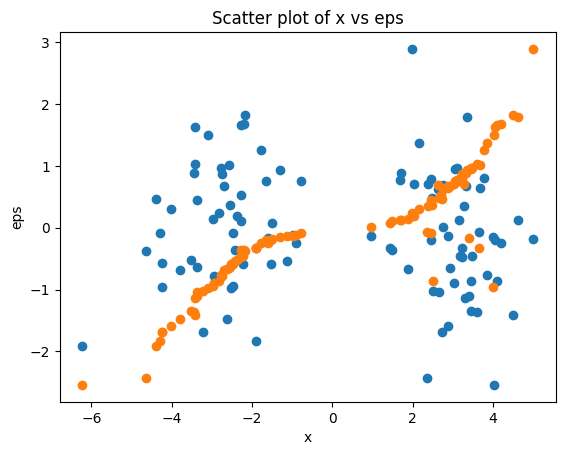

In [260]:
plt.scatter(x, eps)
plt.scatter(x1, eps1)
plt.xlabel('x')
plt.ylabel('eps')
plt.title('Scatter plot of x vs eps')
plt.show()

[3.158]


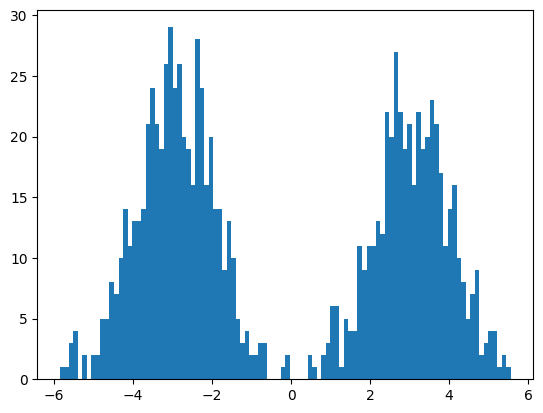

In [261]:
xs = jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 1000))
print(xs.std(0))
_ = plt.hist(xs.flatten(), bins=100)

In [262]:
d = 1
class BaseModel(nnx.Module, experimental_pytree=True):
    def __init__(self, d, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,4, rngs=rngs)
        #self.time_embedding = lambda t: jnp.repeat(t, 5, axis=-1)
        self.mlp = MLP([d+4,50,50,50,d], rngs=rngs)

    def __call__(self, t,x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        inp = jnp.concatenate([time_embed, x], axis=-1)
        output = self.mlp(inp)
        return output

net = BaseModel(1, nnx.Rngs(0))
model = EDM(net, std0=1., loss_kwargs={"copula": ot_copula})
params = nnx.state(model, nnx.Param)

In [263]:

import optax

opt = optax.chain(optax.adaptive_grad_clip(1.), optax.adam(1e-3))
opt_state = opt.init(params)
@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(model.loss)(params, rng,x)
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [264]:
key = jax.random.key(0)

In [274]:
losses = []
for i in range(200):
    l = 0.
    for j in range(10):
        key,key_data, key_loss = jax.random.split(key, 3)
        xs = jax.vmap(generate_data)(jax.random.split(key_data, 100))
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    print(l/10)
    losses.append(l/10)

0.23337002
0.15337913
0.13931094
0.25414702
0.1468558
0.15349904
0.16208236
0.20520654
0.17714977
0.14637296
0.2303767
0.15324593
0.15640311
0.17824827
0.17806526
0.20628944
0.21880507
0.14612678
0.12680458
0.14139645
0.182087
0.15780076
0.15010607
0.1972863
0.24851601
0.23184966
0.16905266
0.14904033
0.18429255
0.16559671
0.13812898
0.18143825
0.15562849
0.18182586
0.15916379
0.17010735
0.1552585
0.17341462
0.16956136
0.21693984
0.15373622
0.1579933
0.21782723
0.2043823
0.1396189
0.18734594
0.15151647
0.18246375
0.2188562
0.19795445
0.17158248
0.15687227
0.1989799
0.1280335
0.15002476
0.14516445
0.14893362
0.16530286
0.15145545
0.19794694
0.15474306
0.15515646
0.16340518
0.15334605
0.14747274
0.14705124
0.1689768
0.1849927
0.13315484
0.15864109
0.20296064
0.12145423
0.12587729
0.14256705
0.13696419
0.16381787
0.181386
0.18795381
0.14179341
0.15865596
0.15373038
0.2063901
0.1914082
0.13776977
0.11875397
0.15573503
0.21065311
0.18767218
0.15334384
0.14353679
0.17831613
0.16970532
0.2039

In [275]:
nnx.update(model, params)

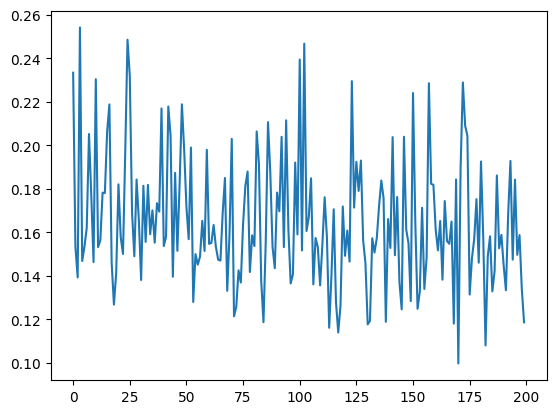

In [276]:
plt.plot(losses)

In [277]:
from probjax.utils.odeint import odeint


def sample(rng):
    eps = jax.random.normal(rng, (d,)) * model.marginal_std(model.max_noise)
    ts = model.solve_schedule()

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x)
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts, method="heun")


In [278]:
model.marginal_std(model.max_noise)

Array([80.006], dtype=float32)

(array([244., 212., 129., 108.,  58.,  63.,  22.,  20.,  26.,  15.,  19.,
          8.,   7.,   9.,   8.,   2.,   6.,  10.,   3.,   2.,   1.,   1.,
          4.,   2.,   1.,   1.,   0.,   1.,   0.,   0.,   1.,   1.,   0.,
          2.,   0.,   1.,   0.,   3.,   0.,   0.,   0.,   1.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   3.,
          1.,   0.,   0.,   0.,   0.,   1.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([ 0.007,  0.268,  0.53 ,  0.791,  1.053,  1.315,  1.576,  1.838,
         2.099,  2.361,  2.623,  2.884,  3.146,  3.407,  3.669,  3.931,
         4.192,  4.454,  4.715,  4.977,  5.239,  5.5  ,  5.762,  6.023,
         6.285,  6.547,  6.808,  7.07 ,  7.331,  7.593,  7.854,  8.116,
         8.378,  8.639,  8.901

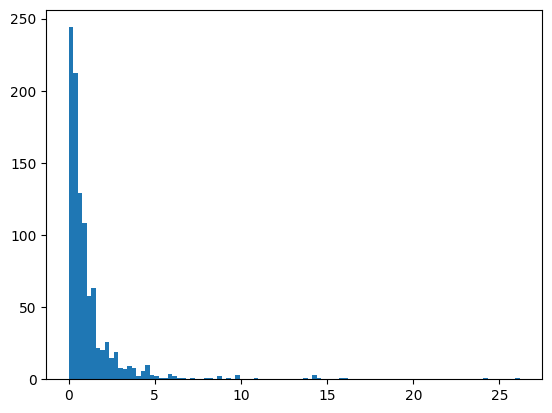

In [279]:
model.lognoise_mean = -0.5
plt.hist(model.noise_schedule(jax.random.key(0), (1000,)).flatten(), bins=100)

In [280]:
keys = jax.random.split(key, (10_000,))
xs = jax.vmap(sample)(keys)

(-10.0, 10.0)

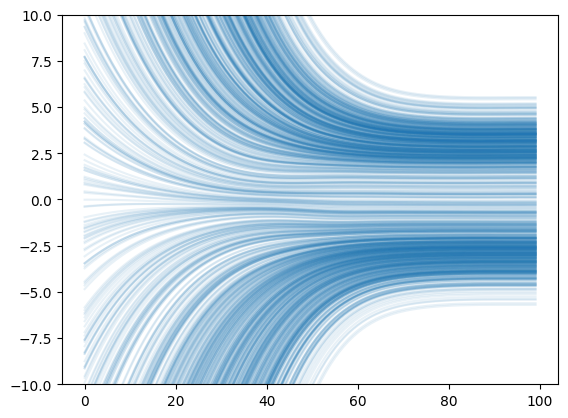

In [281]:
_ = plt.plot(xs[::10,:,0].T, color="C0", alpha=0.1)
plt.ylim(-10,10)

(-7.0, 7.0)

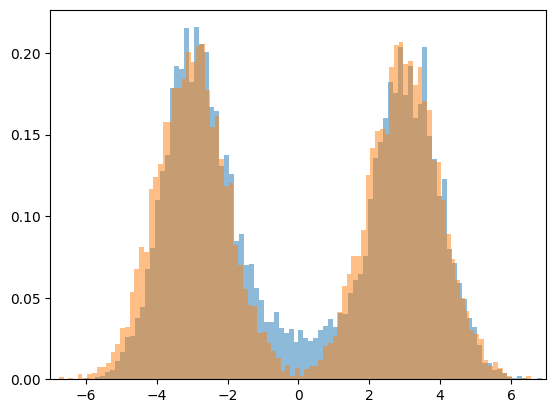

In [283]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, range=(-7,7), alpha=0.5)
_ = plt.hist(jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 10000)).flatten(), bins=100, density=True, alpha=0.5)

plt.xlim(-7,7)

In [284]:
from probjax.utils.sdeint import sdeint


def sample(rng):
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (d,))  * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(50)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t,x)
        score = model.score(t,x)

        drift_backward = f - g**2 * score
        return drift_backward

    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        g = model.diffusion(t,x)
        return g

    return sdeint(rng_sample,drift, diffusion, eps, ts, method="euler_maruyama")





In [285]:
keys = jax.random.split(key, (10_000,))

In [286]:
xs = jax.vmap(sample)(keys)

(-10.0, 10.0)

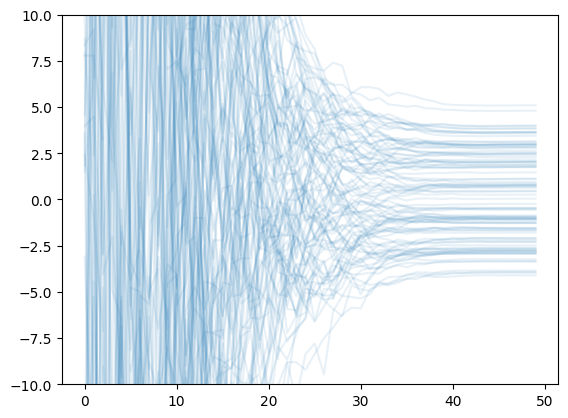

In [287]:
_ = plt.plot(xs[::100,:,0].T, color="C0", alpha=0.1)
plt.ylim(-10,10)

(-7.0, 7.0)

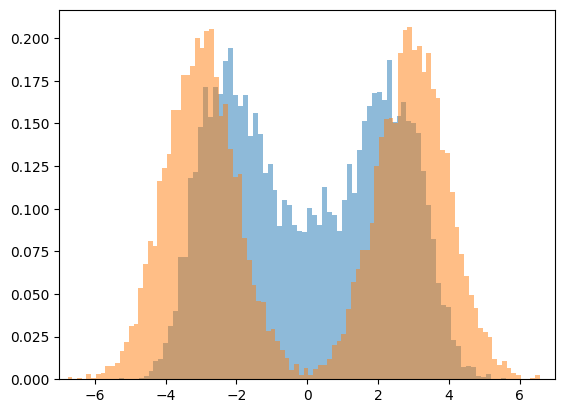

In [288]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, range=(-7,7), alpha=0.5)
_ = plt.hist(jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 10000)).flatten(), bins=100, density=True, alpha=0.5)

plt.xlim(-7,7)